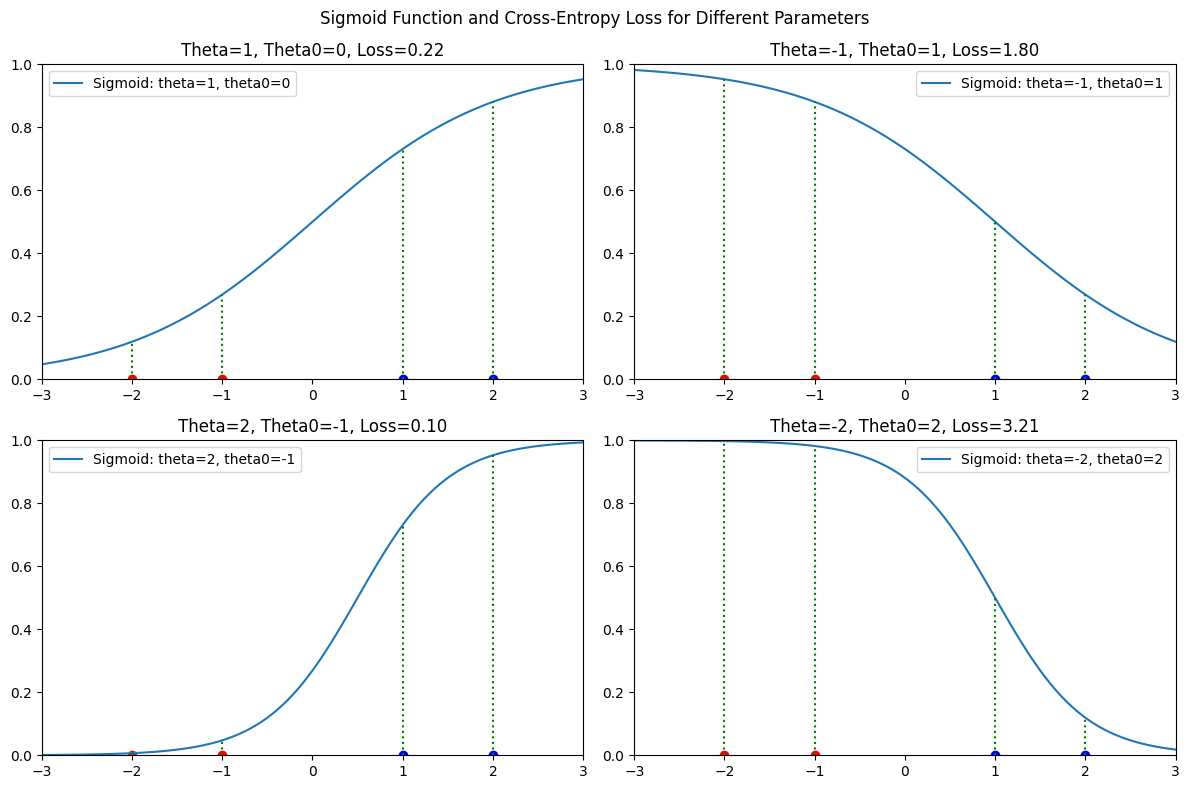

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# x values for sigmoid curve
x = np.linspace(-3, 3, 100)

# training data points
x_points = np.array([-2, -1, 1, 2])
y_labels = np.array([0, 0, 1, 1])

# different parameter settings
parameters = [
    (1, 0),
    (-1, 1),
    (2, -1),
    (-2, 2)
]

# create subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, (theta1, theta0) in enumerate(parameters):

    # sigmoid curve
    z = theta1 * x + theta0
    y = sigmoid(z)

    ax = axes[i]
    ax.plot(x, y, label=f"Sigmoid: theta={theta1}, theta0={theta0}")

    # predictions for given points
    z_points = theta1 * x_points + theta0
    y_pred = sigmoid(z_points)

    # cross entropy loss
    loss = -np.mean(
        y_labels * np.log(y_pred) +
        (1 - y_labels) * np.log(1 - y_pred)
    )

    # plot class points
    ax.scatter(x_points[y_labels == 0], np.zeros(sum(y_labels == 0)), color="red")
    ax.scatter(x_points[y_labels == 1], np.zeros(sum(y_labels == 1)), color="blue")

    # vertical dotted lines
    for xp, yp in zip(x_points, y_pred):
        ax.plot([xp, xp], [0, yp], linestyle="dotted", color="green")

    # titles and limits
    ax.set_title(f"Theta={theta1}, Theta0={theta0}, Loss={loss:.2f}")
    ax.set_xlim(-3, 3)
    ax.set_ylim(0, 1)

    ax.legend()

plt.suptitle("Sigmoid Function and Cross-Entropy Loss for Different Parameters")
plt.tight_layout()
plt.show()